In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text = ''' Data visualization is an interdisciplinary field that deals with the graphic
            representation of data . It is a particularly efficient way of communicating when
            the data is numerous as for example a time series . Excel ’s capabilities of
            managing spreadsheet data through data visualization tools , such as conditional
            formatting and graphing tools , have made it a widely applied data visualization
        tool. '''
wordcloud = WordCloud(random_state=1,
                      width = 500,
                      height = 500,
                      background_color = 'white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

ModuleNotFoundError: No module named 'wordcloud'

In [ ]:
help(WordCloud)

### Procedure for Word Frequency Plots
* Step 1: convert the text to lowercase.
* Step 2: remove punctuation and stopwords.
* Step 3: count the frequencies of selected words.
* Step 4: visualize the top words with a bar chart.

In [ ]:
from collections import Counter

text = '''This is a sample text about data visualization . Data visualization is a
powerful tool for exploring and understanding data . It helps us see patterns and
trends that might be difficult to identify from raw numbers .'''

text = text.lower()
text = ''.join([char for char in text if char.isalnum() or char == ' '])
words = text.split()

stopwords = ["a", "an", " the ", "is", "of", " and ", "to", "in",
            "on", " for ", "it", " with ", "as", "be", " have ",
            "at", "by", "or", " that ", " this ", " from ", " are "]

words = [word for word in words if word not in stopwords]
word_counts = Counter(words)
top_10_words = word_counts.most_common(10)
word_labels = [word for word, _ in top_10_words]
word_values = [count for _, count in top_10_words]  

import matplotlib.pyplot as plt
plt.figure(figsize = (8, 6))
plt.bar(word_labels, word_values)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title(" Top 10 Most Frequent Words ")
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()

### Bigram

In [ ]:
import networkx as nx
from collections import Counter
processed_text ="".join(char.lower() for char in text if char.isalnum() or char.isspace())
words = processed_text.split()
bigrams = zip(words[: -1], words[1:])
bigram_counts = Counter(bigrams)
G = nx.Graph ()
for bigram, count in bigram_counts.items():
    G.add_edge(bigram[0], bigram[1], weight = count)
pos = nx.spring_layout(G, seed = 42)
nx.draw_networkx(G, pos, with_labels = True)

### Workflow for Text Clustering
* Convert documents into numerical features with TF-IDF.
* Reduce dimensionality with LSA / Truncated SVD.
* Apply K-Means or MiniBatch K-Means.
* Visualize the result with PCA and t-SNE.
* Evaluate clusters with quantitative metrics.

* python包jieba 用来中文分词

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_20newsgroups
categories = ["rec.sport.hockey","talk.politics.misc","comp.graphics","sci.space"]
dataset = fetch_20newsgroups(subset = "all", categories = categories, remove = ("headers", "footers", "quotes"), shuffle = True,random_state = 42)
labels = dataset.target
category_sizes = np.bincount(labels)
print(len(dataset.data))

3734


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_df = 0.5, stop_words = "english")  # max_df = 0.5 means that we will ignore terms that appear in more than 50% of the documents, as they are likely to be too common and not informative for our analysis.
X_tfidf = vectorizer.fit_transform(dataset.data)
terms = vectorizer.get_feature_names_out()
print(X_tfidf.shape)

(3734, 36150)


Text(0.5, 1.0, 'Top TF - IDF Words in Corpus')

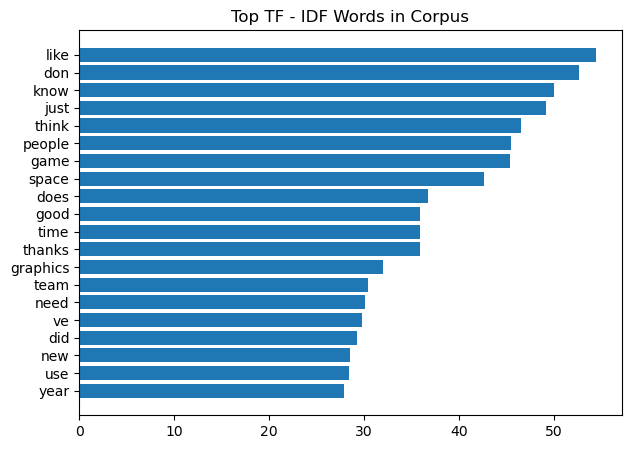

In [ ]:
tfidf_sum = np.asarray(X_tfidf.sum(axis=0)).ravel()
top_indices = tfidf_sum.argsort()[::-1][:20]
top_words = [terms[i] for i in top_indices]
top_scores = tfidf_sum[top_indices]
plt.figure(figsize=(7, 5))
plt.barh(top_words[::-1], top_scores[::-1])
plt.title("Top TF - IDF Words in Corpus")

### Dimensionality Reduction


* PCA

In [4]:
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

lsa = make_pipeline(
    TruncatedSVD(n_components=100, random_state=42), Normalizer(copy=False)
)
X_lsa = lsa.fit_transform(X_tfidf)
explained_var = lsa[0].explained_variance_ratio_.sum()
print(explained_var)

0.14816929005765409


Text(0.5, 1.0, ' PCA Projection of Documents')

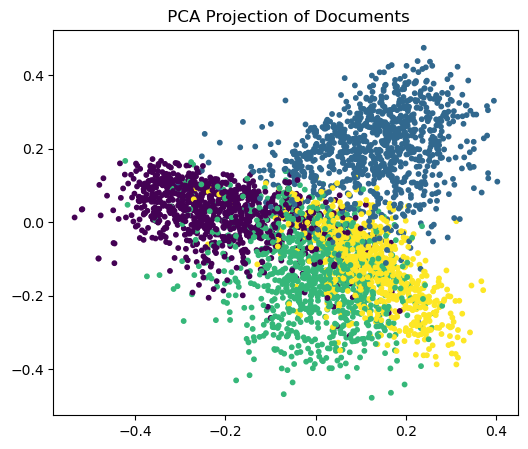

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_lsa)
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=10)
plt.title(" PCA Projection of Documents")

c:\Users\33529\anaconda3\envs\myproject\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=15.
  warnings.warn(


Text(0, 0.5, ' Count ')

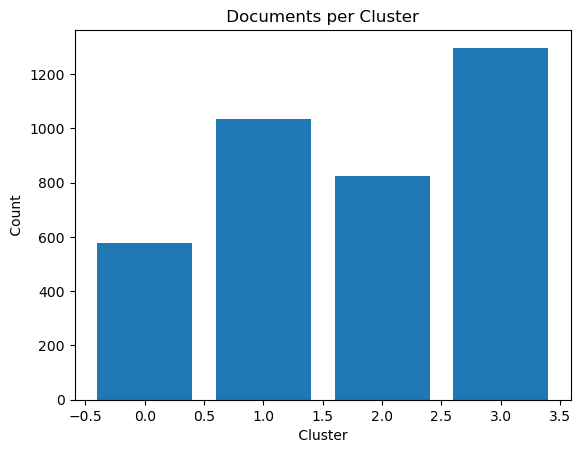

In [6]:
from sklearn.cluster import KMeans

true_k = len(dataset.target_names)
kmeans = KMeans(n_clusters=true_k, max_iter=100, n_init=10, random_state=42)
kmeans.fit(X_lsa)

cluster_ids, cluster_sizes = np.unique(kmeans.labels_, return_counts=True)
plt.bar(cluster_ids, cluster_sizes)
plt.title(" Documents per Cluster ")
plt.xlabel(" Cluster ")
plt.ylabel(" Count ")